#load data

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "clothes_price_prediction_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mrsimple07/clothes-price-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'clothes-price-prediction' dataset.
First 5 records:           Brand Category  Color Size Material  Price
0   New Balance    Dress  White   XS    Nylon    182
1   New Balance    Jeans  Black   XS     Silk     57
2  Under Armour    Dress    Red    M     Wool    127
3          Nike    Shoes  Green    M   Cotton     77
4        Adidas  Sweater  White    M    Nylon    113


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#data overview
print(f"Shape   : {df.shape}")
print(f"Kolom   : {list(df.columns)}")

print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nStatistik Price:\n{df['Price'].describe()}")

Shape   : (1000, 6)
Kolom   : ['Brand', 'Category', 'Color', 'Size', 'Material', 'Price']

Missing values:
Brand       0
Category    0
Color       0
Size        0
Material    0
Price       0
dtype: int64

Statistik Price:
count    1000.000000
mean      106.289000
std        53.695444
min        10.000000
25%        59.750000
50%       108.000000
75%       150.000000
max       199.000000
Name: Price, dtype: float64


# analisis data

In [ ]:
#outlier detection
Q1  = df['Price'].quantile(0.25)
Q3  = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower) | (df['Price'] > upper)]
print(f"Q1       : {Q1}")
print(f"Q3       : {Q3}")
print(f"IQR      : {IQR}")
print(f"Batas bawah (Q1 - 1.5*IQR) : {lower:.2f}")
print(f"Batas atas  (Q3 + 1.5*IQR) : {upper:.2f}")
print(f"Jumlah outlier : {len(outliers)} baris ({len(outliers)/len(df)*100:.1f}%)")
if len(outliers) > 0:
    print(outliers)
else:
    print("Tidak ada outlier")

Q1       : 59.75
Q3       : 150.0
IQR      : 90.25
Batas bawah (Q1 - 1.5*IQR) : -75.62
Batas atas  (Q3 + 1.5*IQR) : 285.38
Jumlah outlier : 0 baris (0.0%)
Tidak ada outlier


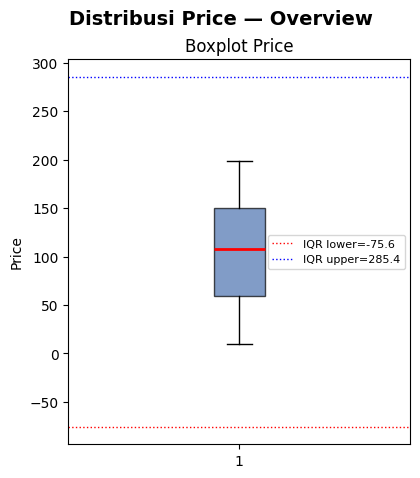

In [ ]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle("Distribusi Price — Overview", fontsize=14, fontweight="bold")

ax2 = fig.add_subplot(1, 3, 2)
ax2.boxplot(df['Price'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#4C72B0', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='orange', markersize=5))
ax2.set_title("Boxplot Price")
ax2.set_ylabel("Price")
ax2.axhline(lower, color='red',  linestyle=':', linewidth=1, label=f"IQR lower={lower:.1f}")
ax2.axhline(upper, color='blue', linestyle=':', linewidth=1, label=f"IQR upper={upper:.1f}")
ax2.legend(fontsize=8)

In [ ]:
print(f"[1] Unique values:\n{df.nunique()}")
cat_cols = ['Brand', 'Category', 'Color', 'Size', 'Material']

for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique → {list(df[col].unique())}")


[1] Unique values:
Brand         6
Category      6
Color         6
Size          6
Material      6
Price       190
dtype: int64
  Brand: 6 unique → ['New Balance', 'Under Armour', 'Nike', 'Adidas', 'Reebok', 'Puma']
  Category: 6 unique → ['Dress', 'Jeans', 'Shoes', 'Sweater', 'Jacket', 'T-shirt']
  Color: 6 unique → ['White', 'Black', 'Red', 'Green', 'Yellow', 'Blue']
  Size: 6 unique → ['XS', 'M', 'XL', 'XXL', 'S', 'L']
  Material: 6 unique → ['Nylon', 'Silk', 'Wool', 'Cotton', 'Polyester', 'Denim']


In [ ]:
print("\n[2] Mean Price per kategori (seharusnya beda signifikan jika real):")
for col in cat_cols:
    group = df.groupby(col)["Price"].mean().round(2)
    print(f"\n  {col}:\n{group.to_string()}")


[2] Mean Price per kategori (seharusnya beda signifikan jika real):

  Brand:
Brand
Adidas          104.05
New Balance     115.46
Nike            101.91
Puma            106.14
Reebok          106.49
Under Armour    103.96

  Category:
Category
Dress      114.51
Jacket     102.83
Jeans      100.75
Shoes      108.57
Sweater    106.78
T-shirt    104.56

  Color:
Color
Black     102.83
Blue      107.06
Green     103.52
Red       106.14
White     113.69
Yellow    104.24

  Size:
Size
L      106.16
M      105.19
S      103.90
XL     102.15
XS     110.12
XXL    109.34

  Material:
Material
Cotton       103.35
Denim        107.69
Nylon        109.39
Polyester    106.43
Silk         101.91
Wool         109.20


In [ ]:
print("\n[3] korelasi fitur dengan price setelah encoding: ")
df_enc = df.copy()
le = LabelEncoder()
for col in cat_cols:
  df_enc[col] = le.fit_transform(df_enc[col])

# Calculate correlation after all categorical columns have been encoded
corr = df_enc.corr()["Price"].drop("Price")
print(corr.round(4))


[3] korelasi fitur dengan price setelah encoding: 
Brand      -0.0214
Category   -0.0252
Color       0.0266
Size        0.0289
Material    0.0080
Name: Price, dtype: float64


#preprocessing

In [ ]:
df_model = df.copy()
cat_cols = ['Brand', 'Category', 'Color', 'Size', 'Material']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df[col])
    le_dict[col] = le

x = df_model.drop(columns=['Price'])
y = df_model['Price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Train size: {x_train.shape[0]} baris")
print(f"Test size: {x_test.shape[0]} baris")
print(f"Fitur: {x.shape[1]} kolom setelah OneHotEncoding")

Train size: 800 baris
Test size: 200 baris
Fitur: 5 kolom setelah OneHotEncoding


In [ ]:
#training dan evaluasi model
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor()
}

result = {}
prediction = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    result[name] = {"MAE": mae, "RMSE": rmse, "R^2": r2}
    prediction[name] = y_pred

    print(f"\n{name}:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  R²   = {r2:.4f}")


Linear Regression:
  MAE  = 46.52
  RMSE = 54.40
  R²   = -0.0099

Decision Tree:
  MAE  = 64.08
  RMSE = 78.77
  R²   = -1.1173

Random Forest:
  MAE  = 48.97
  RMSE = 57.99
  R²   = -0.1477

XGBoost:
  MAE  = 54.58
  RMSE = 67.31
  R²   = -0.5459


In [ ]:
#memilih model terbaik
results_df = pd.DataFrame(result).T.sort_values("R^2", ascending=False)
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"MODEL TERBAIK: {best_model_name}  (R² = {results_df.loc[best_model_name, 'R^2']:.4f})")

MODEL TERBAIK: Linear Regression  (R² = -0.0099)


# SHAP & Model

Disimpan: shap_summary.png


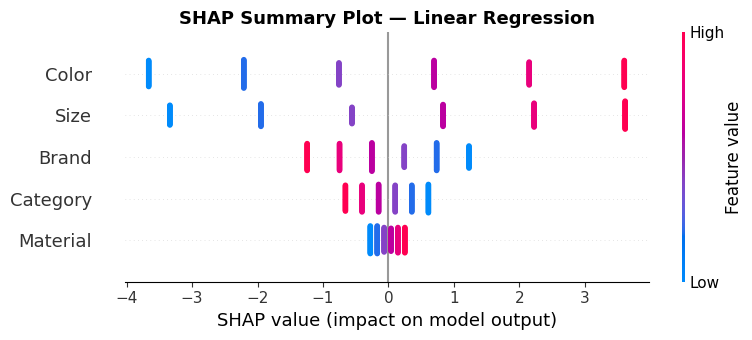

Disimpan: shap_importance.png


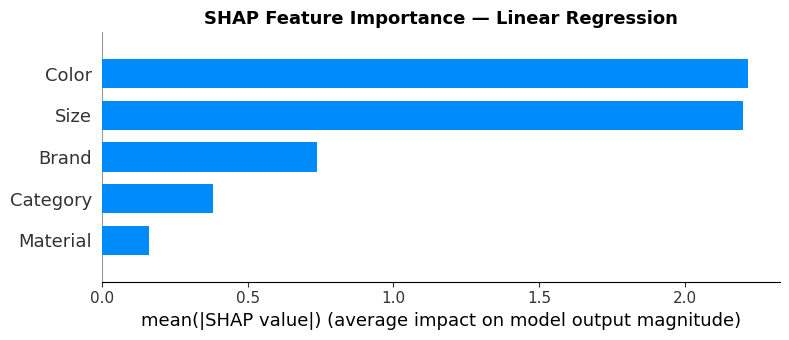

In [ ]:
X_shap = x_test.iloc[:200]

if best_model_name in ("Random Forest", "XGBoost", "Decision Tree"):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
else:
    explainer = shap.LinearExplainer(best_model, x_train)
    shap_values = explainer.shap_values(X_shap)

# SHAP Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.title(f"SHAP Summary Plot — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
print("Disimpan: shap_summary.png")
plt.show()

# SHAP Bar Plot (feature importance rata-rata)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=15)
plt.title(f"SHAP Feature Importance — {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight")
print("Disimpan: shap_importance.png")
plt.show()

Disimpan: actual_vs_predicted.png


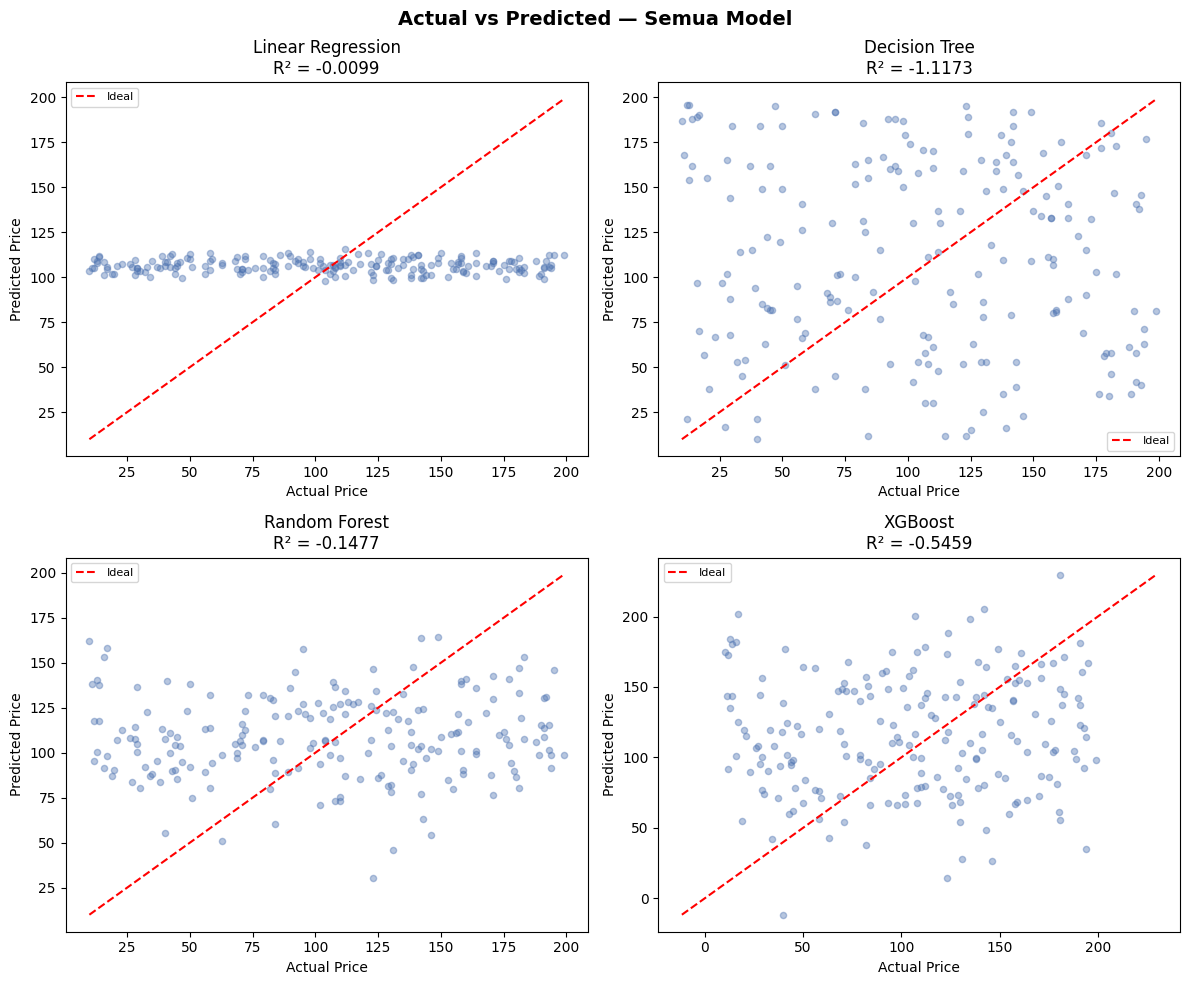

In [ ]:
#actual vs predicted
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Actual vs Predicted — Semua Model", fontsize=14, fontweight="bold")

for ax, (name, y_pred) in zip(axes.flat, prediction.items()):
    r2 = result[name]["R^2"]
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color="#4C72B0")
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Ideal")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(f"{name}\nR² = {r2:.4f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
print("Disimpan: actual_vs_predicted.png")
plt.show()

In [ ]:
print("Ringkasan Evaluasi Model")
print(results_df.round(4).to_string())

# Top SHAP features
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print("\nTOP 10 FITUR PALING BERPENGARUH (SHAP)")
print(mean_shap.head(10).round(4).to_string())

Ringkasan Evaluasi Model
                       MAE     RMSE     R^2
Linear Regression  46.5176  54.4009 -0.0099
Random Forest      48.9650  57.9931 -0.1477
XGBoost            54.5767  67.3078 -0.5459
Decision Tree      64.0850  78.7704 -1.1173

TOP 10 FITUR PALING BERPENGARUH (SHAP)
Color       2.2169
Size        2.2002
Brand       0.7399
Category    0.3803
Material    0.1627


Kontribusi Fitur terhadap Prediksi Harga (Linear Regression)
  Color       :  38.9%  ███████████████████
  Size        :  38.6%  ███████████████████
  Brand       :  13.0%  ██████
  Category    :   6.7%  ███
  Material    :   2.9%  █


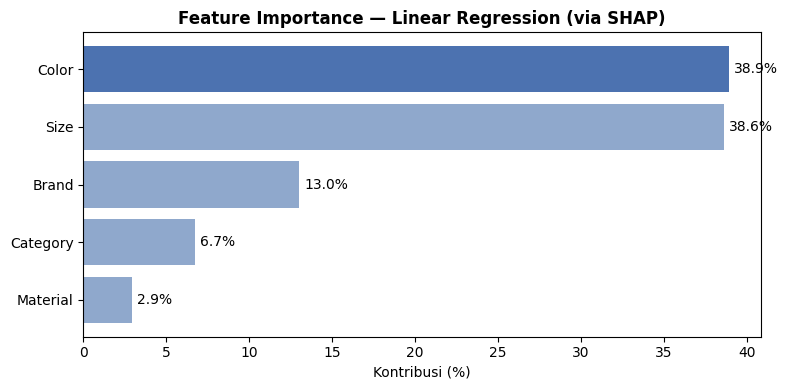

In [ ]:
#Kontribusi Fitur dalam Persen dari SHAP best model
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap.columns
)

shap_pct = (mean_shap / mean_shap.sum() * 100).sort_values(ascending=False).round(1)

print(f"Kontribusi Fitur terhadap Prediksi Harga ({best_model_name})")
print("=" * 45)
for feat, pct in shap_pct.items():
    bar = "█" * int(pct / 2)
    print(f"  {feat:12s}: {pct:5.1f}%  {bar}")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4C72B0" if i == 0 else "#8FA8CC" for i in range(len(shap_pct))]
ax.barh(shap_pct.index[::-1], shap_pct.values[::-1], color=colors[::-1])
ax.set_xlabel("Kontribusi (%)")
ax.set_title(f"Feature Importance — {best_model_name} (via SHAP)", fontweight="bold")
for i, (val, name) in enumerate(zip(shap_pct.values[::-1], shap_pct.index[::-1])):
    ax.text(val + 0.3, i, f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("shap_persen.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#tabel harga vs tabel prediksi
comparison_df = pd.DataFrame({
    'Harga Asli'     : y_test.values,
    'Harga Prediksi' : prediction[best_model_name],
    'Selisih'        : prediction[best_model_name] - y_test.values,
    'Selisih (%)'    : ((prediction[best_model_name] - y_test.values) / y_test.values * 100)
}).round(2)

# Tambah info produk (Brand, Category, dll) dari data test
test_info = df.iloc[x_test.index][cat_cols].reset_index(drop=True)
comparison_df = pd.concat([test_info.reset_index(drop=True), comparison_df.reset_index(drop=True)], axis=1)

# Tampilkan 20 sampel
print(f"Harga Asli vs Prediksi — {best_model_name}")
print("-" * 80)
print(comparison_df.head(20).to_string(index=False))

# Ringkasan akurasi
print(f"\nRingkasan:")
print(f"  Rata-rata selisih absolut : ${comparison_df['Selisih'].abs().mean():.2f}")
print(f"  Prediksi terlalu tinggi   : {(comparison_df['Selisih'] > 0).sum()} produk")
print(f"  Prediksi terlalu rendah   : {(comparison_df['Selisih'] < 0).sum()} produk")
print(f"  Prediksi tepat (±5%)      : {(comparison_df['Selisih (%)'].abs() <= 5).sum()} produk")

Harga Asli vs Prediksi — Linear Regression
--------------------------------------------------------------------------------
       Brand Category  Color Size  Material  Harga Asli  Harga Prediksi  Selisih  Selisih (%)
Under Armour    Dress  Green    S     Denim         101          104.16     3.16         3.13
 New Balance    Dress  White  XXL     Nylon         164          113.32   -50.68       -30.90
      Reebok   Jacket  White   XL      Wool          58          109.12    51.12        88.14
        Nike  T-shirt  Black   XL      Wool          82          103.28    21.28        25.95
 New Balance  T-shirt   Blue   XL    Cotton         177          104.70   -72.30       -40.85
        Nike  Sweater  Black    M    Cotton          79          100.22    21.22        26.86
Under Armour   Jacket  Black  XXL Polyester          38          105.38    67.38       177.32
      Adidas    Jeans  Black  XXL    Cotton         118          107.28   -10.72        -9.08
        Puma    Shoes    Red  